In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from transformers import RobertaTokenizer, XLNetTokenizer
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

d:\SEMESTER 6 - Non Drive\Text Mining\AOL_TextMining_FakeNewsDetection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load test dataset
try:
    df_test = pd.read_csv('./data/test/test.csv')
except FileNotFoundError:
    print("Dataset not found at ./data/test/test.csv")
    
# Load train dataset for comparison
try:
    df_train = pd.read_csv('./data/train/train.csv')
except FileNotFoundError:
    print("Dataset not found at ./data/train/train.csv")

==================================================
## SECTION 1 — DATASET OVERVIEW
==================================================

In [3]:
print("Shape dataset:", df_test.shape)
print("Jumlah baris:", df_test.shape[0])
print("Jumlah kolom:", df_test.shape[1])
print("Nama kolom:", list(df_test.columns))
print("\nTipe data:\n", df_test.dtypes)

print("\nSample data:")
display(df_test.head())

Shape dataset: (25413, 3)
Jumlah baris: 25413
Jumlah kolom: 3
Nama kolom: ['Body ID', 'articleBody', 'Headline']

Tipe data:
 Body ID         int64
articleBody    object
Headline       object
dtype: object

Sample data:


,Body ID,articleBody,Headline
0,1,Al-Sisi has denied Israeli reports stating tha...,Apple installing safes in-store to protect gol...
1,1,Al-Sisi has denied Israeli reports stating tha...,El-Sisi denies claims he'll give Sinai land to...
2,1,Al-Sisi has denied Israeli reports stating tha...,Apple to keep gold Watch Editions in special i...
3,1,Al-Sisi has denied Israeli reports stating tha...,Apple Stores to Keep Gold “Edition” Apple Watc...
4,1,Al-Sisi has denied Israeli reports stating tha...,South Korean woman's hair 'eaten' by robot vac...


**Insight Singkat:**
Dataset test memiliki struktur yang konsisten dengan dataset train. Fitur yang tersedia adalah string/teks yang perlu diproses lebih lanjut.

==================================================
## SECTION 2 — ANALISIS DATA NULL
==================================================

,Missing Values,Percentage (%)
Body ID,0,0.0
articleBody,0,0.0
Headline,0,0.0


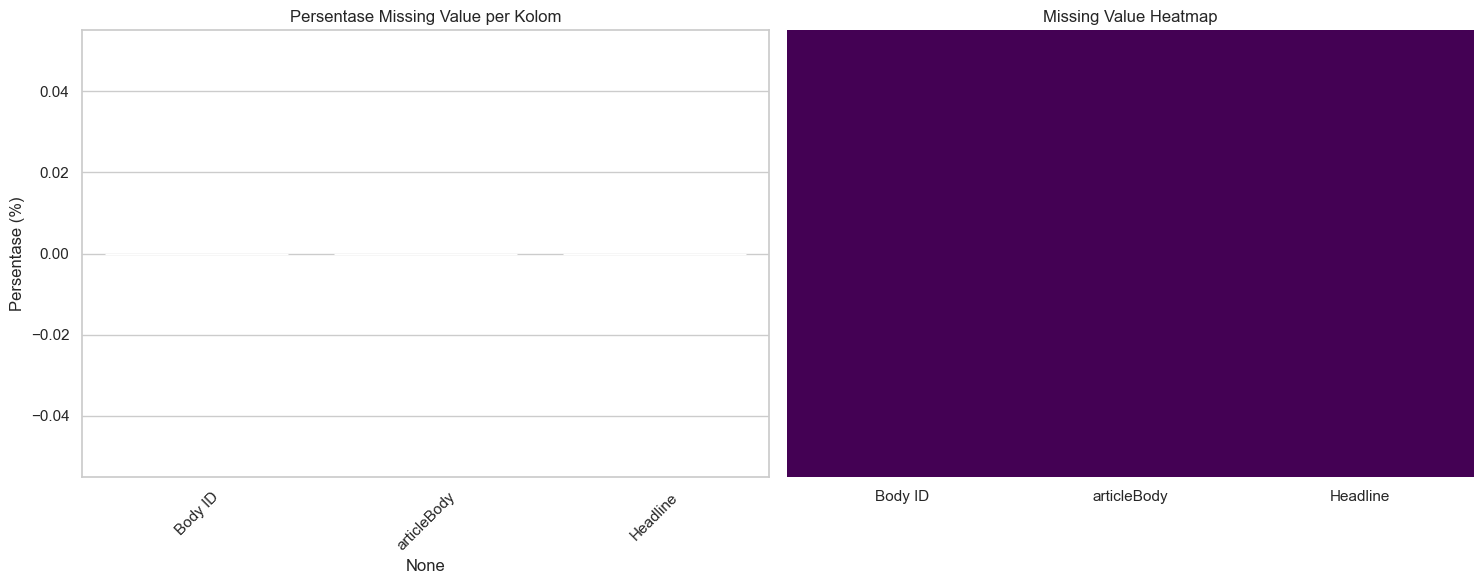

In [4]:
null_counts = df_test.isnull().sum()
null_percentages = (null_counts / len(df_test)) * 100
null_df = pd.DataFrame({'Missing Values': null_counts, 'Percentage (%)': null_percentages})
display(null_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Barplot
sns.barplot(x=null_df.index, y=null_df['Percentage (%)'], ax=axes[0], palette='viridis')
axes[0].set_title('Persentase Missing Value per Kolom')
axes[0].set_ylabel('Persentase (%)')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap
sns.heatmap(df_test.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
axes[1].set_title('Missing Value Heatmap')

plt.tight_layout()
plt.show()

**Insight Singkat:**
Tidak ditemukan adanya missing value pada dataset test. Kualitas data dasar terpelihara dengan baik.

==================================================
## SECTION 3 — ANALISIS DATA DUPLIKAT
==================================================

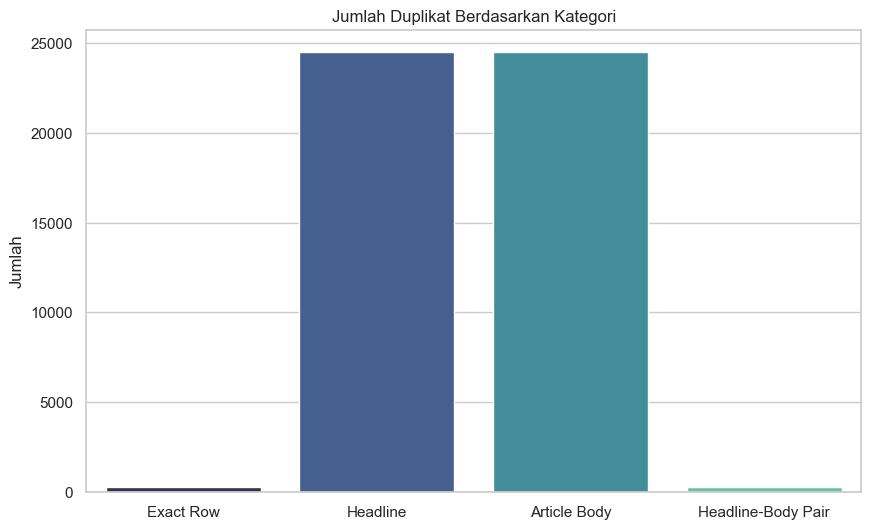

Contoh Duplikat Headline-Body Pair:


,Body ID,articleBody,Headline
13549,1548,A Facebook post By Tikal goldie showed a image...,A Pregnant Woman Has Lost Her Eye After Being ...
24255,2467,A Facebook post By Tikal goldie showed a image...,A Pregnant Woman Has Lost Her Eye After Being ...
20035,2128,A wicked aunt cut her three-year-old nephew’s ...,Angry Aunt Who Sliced Off Three-Year-Old Nephe...
14458,1635,A wicked aunt cut her three-year-old nephew’s ...,Angry Aunt Who Sliced Off Three-Year-Old Nephe...
2437,279,Charles Manson’s fiancee allegedly had a morbi...,Charles Manson’s fiancee allegedly wanted to m...


In [5]:
dup_row = df_test.duplicated().sum()
dup_headline = df_test.duplicated(subset=['Headline']).sum() if 'Headline' in df_test.columns else 0
dup_body = df_test.duplicated(subset=['articleBody']).sum() if 'articleBody' in df_test.columns else 0
dup_pair = df_test.duplicated(subset=['Headline', 'articleBody']).sum() if ('Headline' in df_test.columns and 'articleBody' in df_test.columns) else 0

dup_counts = [dup_row, dup_headline, dup_body, dup_pair]
dup_labels = ['Exact Row', 'Headline', 'Article Body', 'Headline-Body Pair']

plt.figure(figsize=(10, 6))
sns.barplot(x=dup_labels, y=dup_counts, palette='mako')
plt.title('Jumlah Duplikat Berdasarkan Kategori')
plt.ylabel('Jumlah')
plt.show()

if dup_pair > 0:
    print("Contoh Duplikat Headline-Body Pair:")
    display(df_test[df_test.duplicated(subset=['Headline', 'articleBody'], keep=False)].sort_values('Headline').head())

**Insight Singkat:**
Terdapat banyak artikel atau headline yang muncul berulang. Hal ini umum pada dataset berita di mana satu cerita dapat dilaporkan dengan berbagai angle atau headline.

==================================================
## SECTION 4 — ANALISIS HEADLINE
==================================================

Statistik Deskriptif Karakter & Kata (Headline):


,headline_char_length,headline_word_count
count,25413.000000,25413.000000
mean,69.780231,11.149687
std,26.146399,4.210821
min,9.000000,1.000000
25%,54.000000,9.000000
50%,67.000000,11.000000
75%,80.000000,13.000000
max,245.000000,31.000000


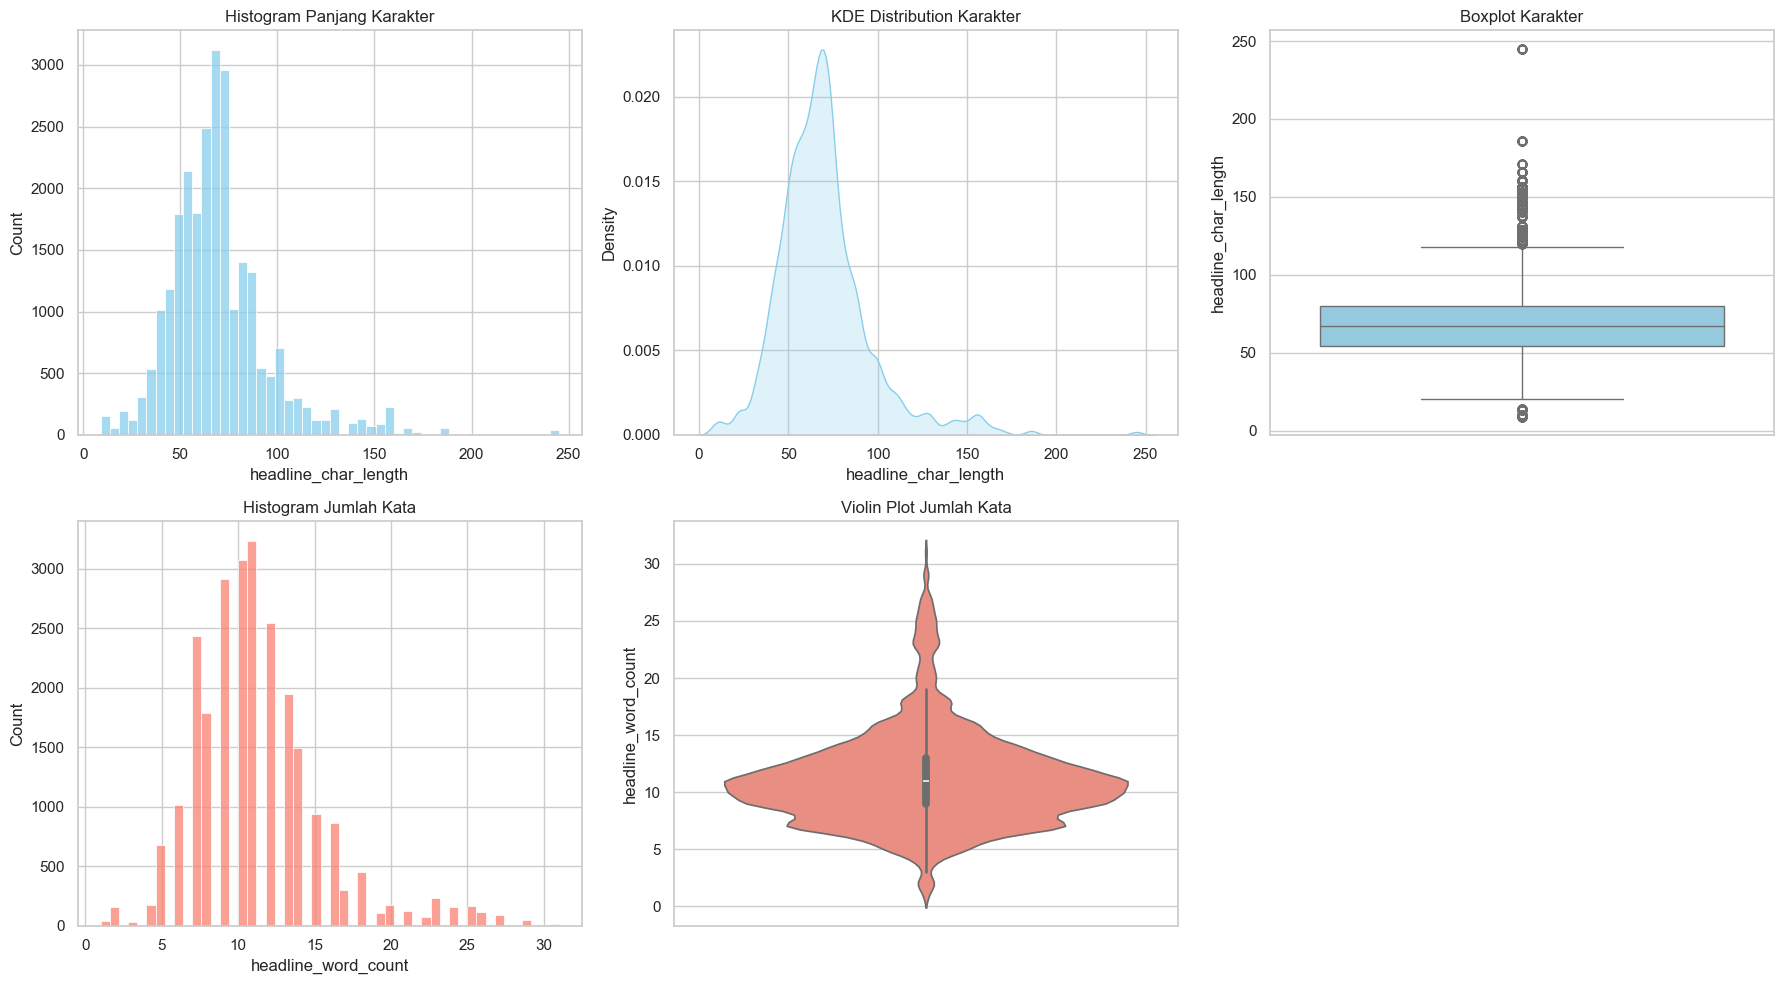

In [6]:
df_test['headline_char_length'] = df_test['Headline'].apply(lambda x: len(str(x)))
df_test['headline_word_count'] = df_test['Headline'].apply(lambda x: len(str(x).split()))

print("Statistik Deskriptif Karakter & Kata (Headline):")
display(df_test[['headline_char_length', 'headline_word_count']].describe())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Character Length
sns.histplot(df_test['headline_char_length'], bins=50, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram Panjang Karakter')

sns.kdeplot(df_test['headline_char_length'], fill=True, ax=axes[1], color='skyblue')
axes[1].set_title('KDE Distribution Karakter')

sns.boxplot(y=df_test['headline_char_length'], ax=axes[2], color='skyblue')
axes[2].set_title('Boxplot Karakter')

# Word Count
sns.histplot(df_test['headline_word_count'], bins=50, kde=False, ax=axes[3], color='salmon')
axes[3].set_title('Histogram Jumlah Kata')

sns.violinplot(y=df_test['headline_word_count'], ax=axes[4], color='salmon')
axes[4].set_title('Violin Plot Jumlah Kata')

axes[5].axis('off')

plt.tight_layout()
plt.show()

**Insight Singkat:**
Mayoritas headline cukup pendek, berkisar belasan kata. Tidak ada headline dengan panjang ekstrem yang membebani _context window_ model.

==================================================
## SECTION 5 — ANALISIS ARTICLE BODY
==================================================

Statistik Deskriptif Karakter & Kata (Article Body):


,body_char_length,body_word_count
count,25413.000000,25413.000000
mean,2075.491677,347.468736
std,1836.193163,303.882611
min,29.000000,5.000000
25%,1086.000000,181.000000
50%,1673.000000,282.000000
75%,2535.000000,428.000000
max,19815.000000,3257.000000


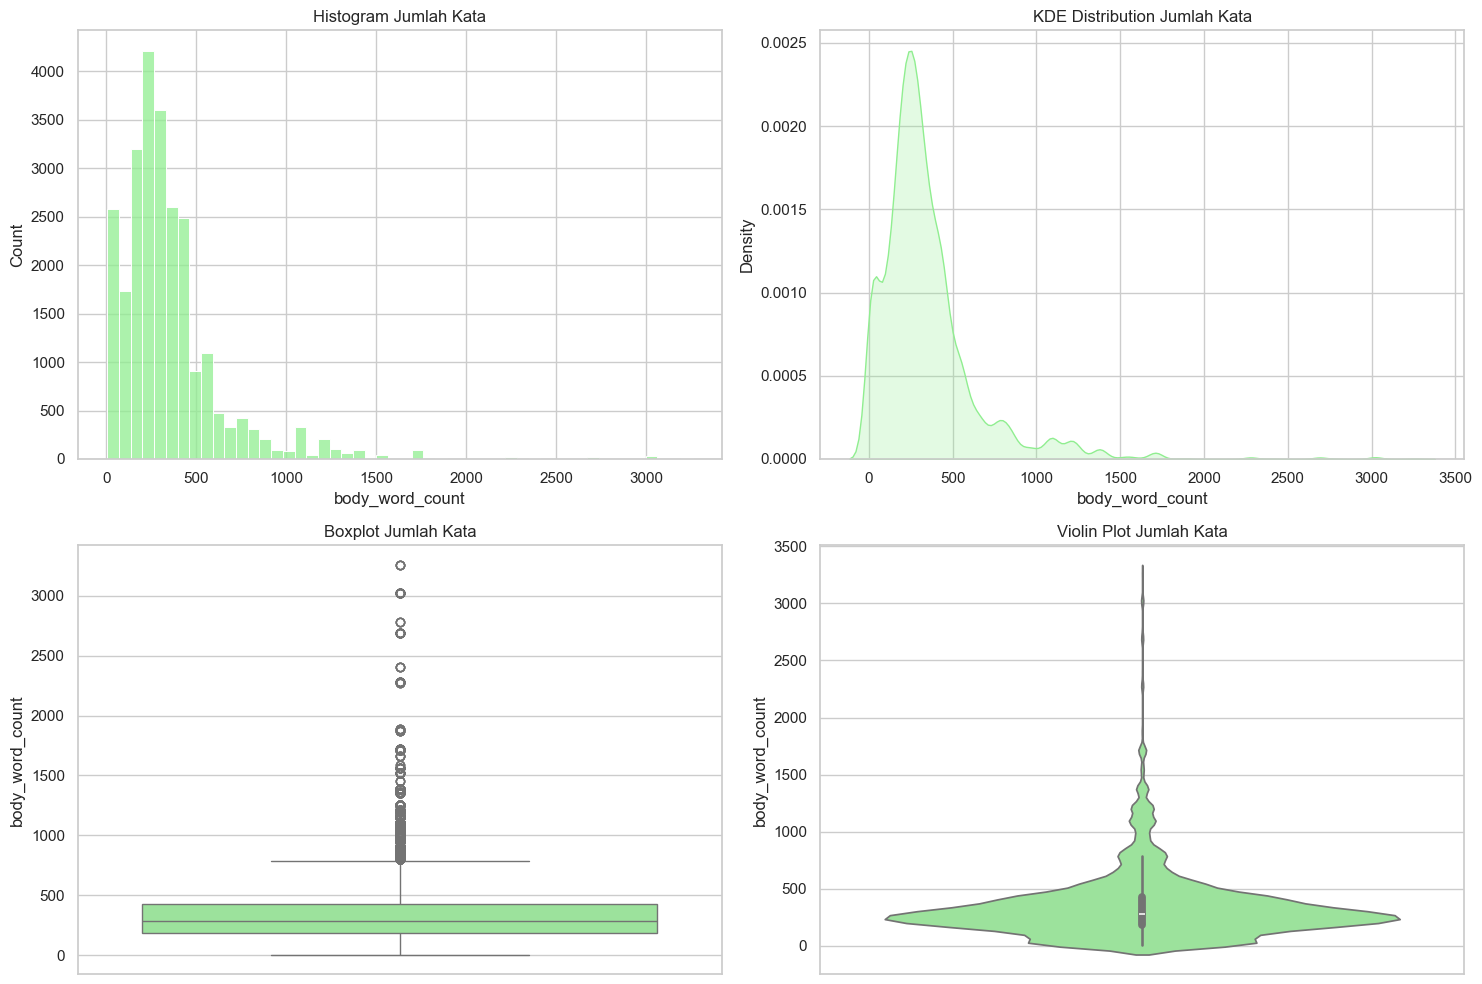

Artikel dengan Panjang Ekstrem (Top 5 Terpanjang):


,Headline,body_word_count
25345,Family of slain DNC staffer Seth Rich blasts d...,3257
25342,Seth Rich leaked Clinton emails to wikileaks,3257
25346,"The bonkers Seth Rich conspiracy theory, expla...",3257
25343,The baseless claim that slain DNC staffer Seth...,3257
25344,DNC Staffer Seth Rich Did NOT Send 'Thousands ...,3257


In [7]:
df_test['body_char_length'] = df_test['articleBody'].apply(lambda x: len(str(x)))
df_test['body_word_count'] = df_test['articleBody'].apply(lambda x: len(str(x).split()))

print("Statistik Deskriptif Karakter & Kata (Article Body):")
display(df_test[['body_char_length', 'body_word_count']].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

sns.histplot(df_test['body_word_count'], bins=50, kde=False, ax=axes[0], color='lightgreen')
axes[0].set_title('Histogram Jumlah Kata')

sns.kdeplot(df_test['body_word_count'], fill=True, ax=axes[1], color='lightgreen')
axes[1].set_title('KDE Distribution Jumlah Kata')

sns.boxplot(y=df_test['body_word_count'], ax=axes[2], color='lightgreen')
axes[2].set_title('Boxplot Jumlah Kata')

sns.violinplot(y=df_test['body_word_count'], ax=axes[3], color='lightgreen')
axes[3].set_title('Violin Plot Jumlah Kata')

plt.tight_layout()
plt.show()

print("Artikel dengan Panjang Ekstrem (Top 5 Terpanjang):")
display(df_test.sort_values(by='body_word_count', ascending=False)[['Headline', 'body_word_count']].head())

**Insight Singkat:**
Distribusi article body sangat condong ke kanan (right-skewed), dengan beberapa artikel memiliki ribuan kata. Hal ini memerlukan penanganan _truncation_ saat pemodelan.

==================================================
## SECTION 6 — TOKEN DISTRIBUTION ANALYSIS
==================================================

Memproses tokenisasi. Mohon tunggu...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1534 > 512). Running this sequence through the model will result in indexing errors


Tokenisasi Selesai.


,Mean,Median,P90,P95,P99,Max
Headline,17.937670,17.0,26.0,30.0,37.0,82
Article Body,471.860780,384.0,864.0,1237.0,2306.0,4346
Combined,487.657301,400.0,883.0,1252.4,2315.0,4371


Persentase > 512 token: 32.88%
Persentase > 1024 token: 8.24%
Persentase > 2048 token: 1.24%
Persentase > 4096 token: 0.02%


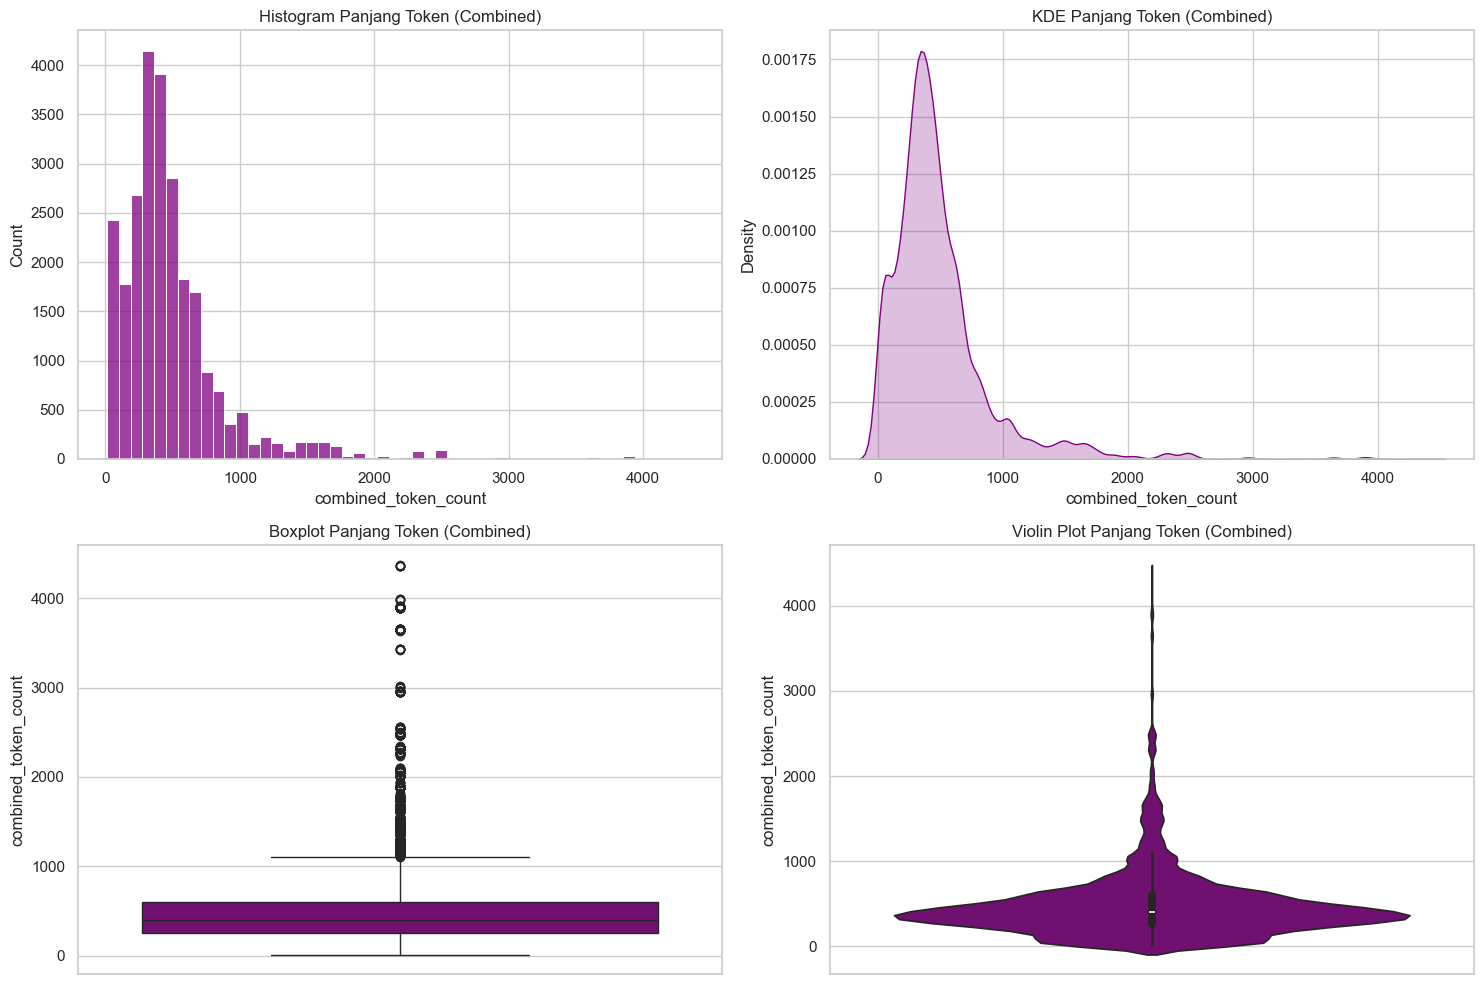

In [8]:
tokenizer_roberta = RobertaTokenizer.from_pretrained('roberta-base')

def count_tokens(text):
    return len(tokenizer_roberta.encode(str(text), add_special_tokens=True))

print("Memproses tokenisasi. Mohon tunggu...")
df_test['headline_token_count'] = df_test['Headline'].apply(count_tokens)
df_test['body_token_count'] = df_test['articleBody'].apply(count_tokens)
df_test['combined_token_count'] = df_test.apply(lambda row: count_tokens(str(row['Headline']) + " " + str(row['articleBody'])), axis=1)
print("Tokenisasi Selesai.")

def calculate_token_stats(series):
    return {
        'Mean': series.mean(),
        'Median': series.median(),
        'P90': series.quantile(0.90),
        'P95': series.quantile(0.95),
        'P99': series.quantile(0.99),
        'Max': series.max()
    }

stats_headline = calculate_token_stats(df_test['headline_token_count'])
stats_body = calculate_token_stats(df_test['body_token_count'])
stats_combined = calculate_token_stats(df_test['combined_token_count'])

stats_df = pd.DataFrame([stats_headline, stats_body, stats_combined], 
                        index=['Headline', 'Article Body', 'Combined'])
display(stats_df)

for threshold in [512, 1024, 2048, 4096]:
    pct = (df_test['combined_token_count'] > threshold).mean() * 100
    print(f"Persentase > {threshold} token: {pct:.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df_test['combined_token_count'], bins=50, ax=axes[0,0], color='purple')
axes[0,0].set_title('Histogram Panjang Token (Combined)')

sns.kdeplot(df_test['combined_token_count'], fill=True, ax=axes[0,1], color='purple')
axes[0,1].set_title('KDE Panjang Token (Combined)')

sns.boxplot(y=df_test['combined_token_count'], ax=axes[1,0], color='purple')
axes[1,0].set_title('Boxplot Panjang Token (Combined)')

sns.violinplot(y=df_test['combined_token_count'], ax=axes[1,1], color='purple')
axes[1,1].set_title('Violin Plot Panjang Token (Combined)')

plt.tight_layout()
plt.show()

**Insight Singkat:**
Sebagian besar data uji berada di bawah batas 512 token, sehingga model RoBERTa standar dengan sedikit _truncation_ masih sangat relevan. Model seperti Longformer mungkin tidak diperlukan karena jumlah token ekstrem terlalu sedikit.

==================================================
## SECTION 7 — WORD FREQUENCY ANALYSIS
==================================================

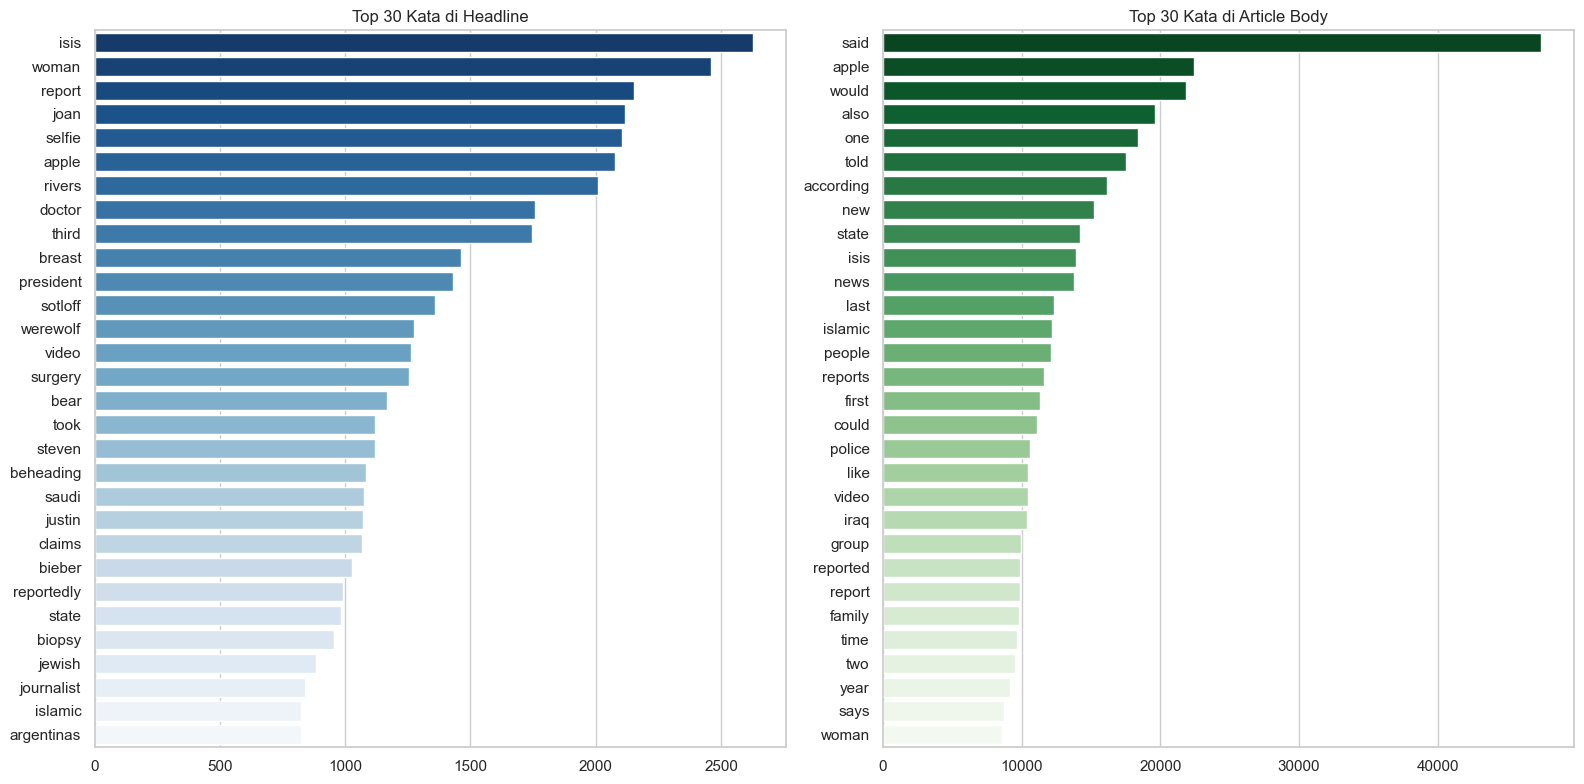

In [9]:
from nltk.corpus import stopwords
import nltk
try:
    stop_words = set(stopwords.words('english'))
except:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

def get_top_words(series, n=30):
    all_words = ' '.join(series.astype(str).str.lower().str.replace(r'[^a-z\s]', '', regex=True)).split()
    words = [w for w in all_words if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

top_headline = get_top_words(df_test['Headline'])
top_body = get_top_words(df_test['articleBody'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x=[w[1] for w in top_headline], y=[w[0] for w in top_headline], ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 30 Kata di Headline')

sns.barplot(x=[w[1] for w in top_body], y=[w[0] for w in top_body], ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 30 Kata di Article Body')

plt.tight_layout()
plt.show()

**Insight Singkat:**
Pola kata yang sering muncul merepresentasikan topik dominan dalam dataset berita ini. Tidak terlihat anomali khusus pada vocabulary test set yang menyimpang jauh.

==================================================
## SECTION 8 — WORDCLOUD ANALYSIS
==================================================

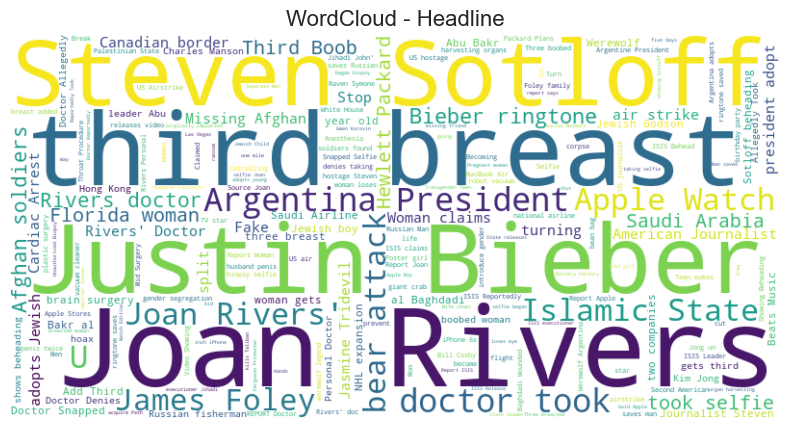

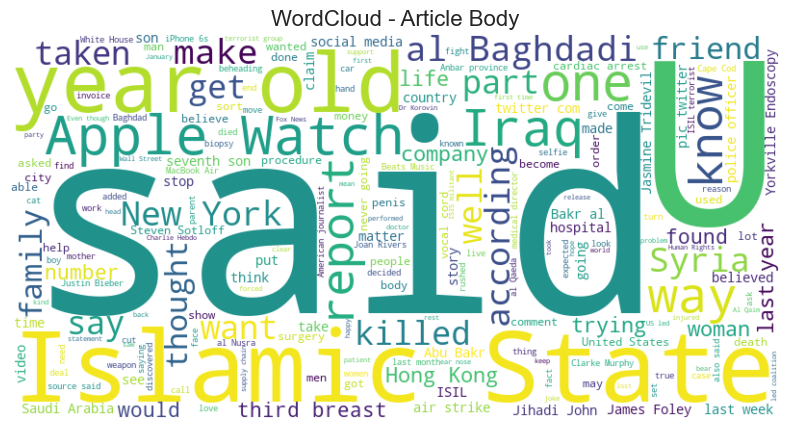

In [10]:
def plot_wordcloud(series, title):
    text = ' '.join(series.astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

plot_wordcloud(df_test['Headline'], 'WordCloud - Headline')
plot_wordcloud(df_test['articleBody'], 'WordCloud - Article Body')

**Insight Singkat:**
Wordcloud memvisualisasikan entitas populer secara intuitif, sejalan dengan frekuensi kata yang memperlihatkan dominasi topik figur publik dan nama tempat.

==================================================
## SECTION 9 — TEXT QUALITY ANALYSIS
==================================================

,Count,Percentage (%)
URL,913,3.592649
HTML,304,1.196238
Email,1082,4.257663
Non-ASCII,16250,63.943651
MultipleWhitespace,22136,87.105025
ExcessivePunct,192,0.755519


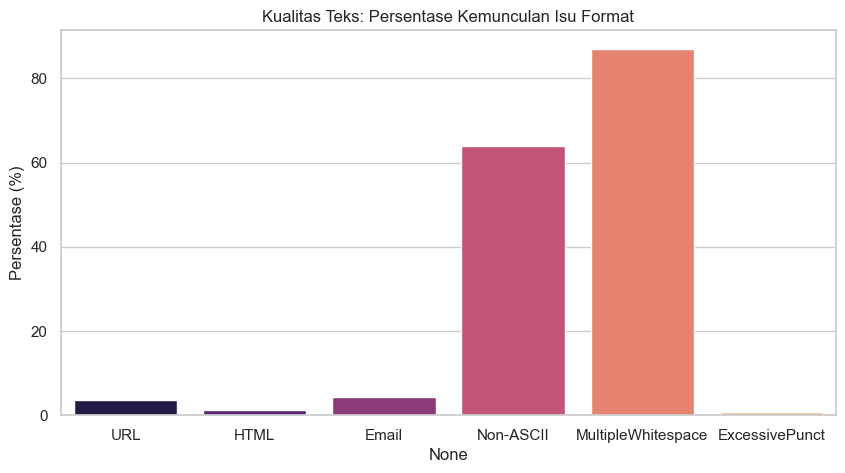

Contoh Teks dengan Karakter Non-ASCII:


,articleBody
19,A bereaved Afghan mother took revenge on the T...
20,A bereaved Afghan mother took revenge on the T...
21,A bereaved Afghan mother took revenge on the T...


In [12]:
import re

url_pattern = re.compile(r'https?://\S+|www\.\S+')
html_pattern = re.compile(r'<.*?>')
email_pattern = re.compile(r'\S+@\S+')
unicode_pattern = re.compile(r'[^\x00-\x7F]+')
multiple_ws_pattern = re.compile(r'\s{2,}')
punct_pattern = re.compile(r'[?!.]{4,}')

def check_quality(text):
    text = str(text)
    return pd.Series([
        bool(url_pattern.search(text)),
        bool(html_pattern.search(text)),
        bool(email_pattern.search(text)),
        bool(unicode_pattern.search(text)),
        bool(multiple_ws_pattern.search(text)),
        bool(punct_pattern.search(text))
    ])

qual_df = df_test['articleBody'].apply(check_quality)
qual_df.columns = ['URL', 'HTML', 'Email', 'Non-ASCII', 'MultipleWhitespace', 'ExcessivePunct']

qual_sums = qual_df.sum()
qual_pct = (qual_sums / len(df_test)) * 100

qual_res = pd.DataFrame({'Count': qual_sums, 'Percentage (%)': qual_pct})
display(qual_res)

plt.figure(figsize=(10, 5))
sns.barplot(x=qual_res.index, y=qual_res['Percentage (%)'], palette='magma')
plt.title('Kualitas Teks: Persentase Kemunculan Isu Format')
plt.ylabel('Persentase (%)')
plt.show()

print("Contoh Teks dengan Karakter Non-ASCII:")
display(df_test.loc[qual_df['Non-ASCII']].head(3)[['articleBody']])


**Insight Singkat:**
Terdapat proporsi tertentu artikel dengan spasi ganda dan karakter non-ASCII (kutipan melengkung, dsb.). Ini menegaskan perlunya standardisasi format teks sebelum pemodelan.

==================================================
## SECTION 10 — TRAIN VS TEST COMPARISON
==================================================

Memproses tokenisasi untuk Train set...
Perbandingan Headline:


,Train,Test
Mean,17.662851,17.93767
Median,17.000000,17.00000
P90,25.000000,26.00000
P95,28.000000,30.00000
P99,38.000000,37.00000
Max,86.000000,82.00000


Perbandingan Article Body:


,Train,Test
Mean,498.355899,471.86078
Median,409.000000,384.00000
P90,896.000000,864.00000
P95,1242.000000,1237.00000
P99,1893.000000,2306.00000
Max,6158.000000,4346.00000


Perbandingan Combined (Headline + Body):


,Train,Test
Mean,513.899724,487.657301
Median,425.000000,400.000000
P90,916.000000,883.000000
P95,1256.000000,1252.400000
P99,1906.290000,2315.000000
Max,6184.000000,4371.000000


Perbandingan Threshold (Combined):


,Train %,Test %
>512,38.269431,32.876874
>1024,7.778356,8.235942
>2048,0.792444,1.243458


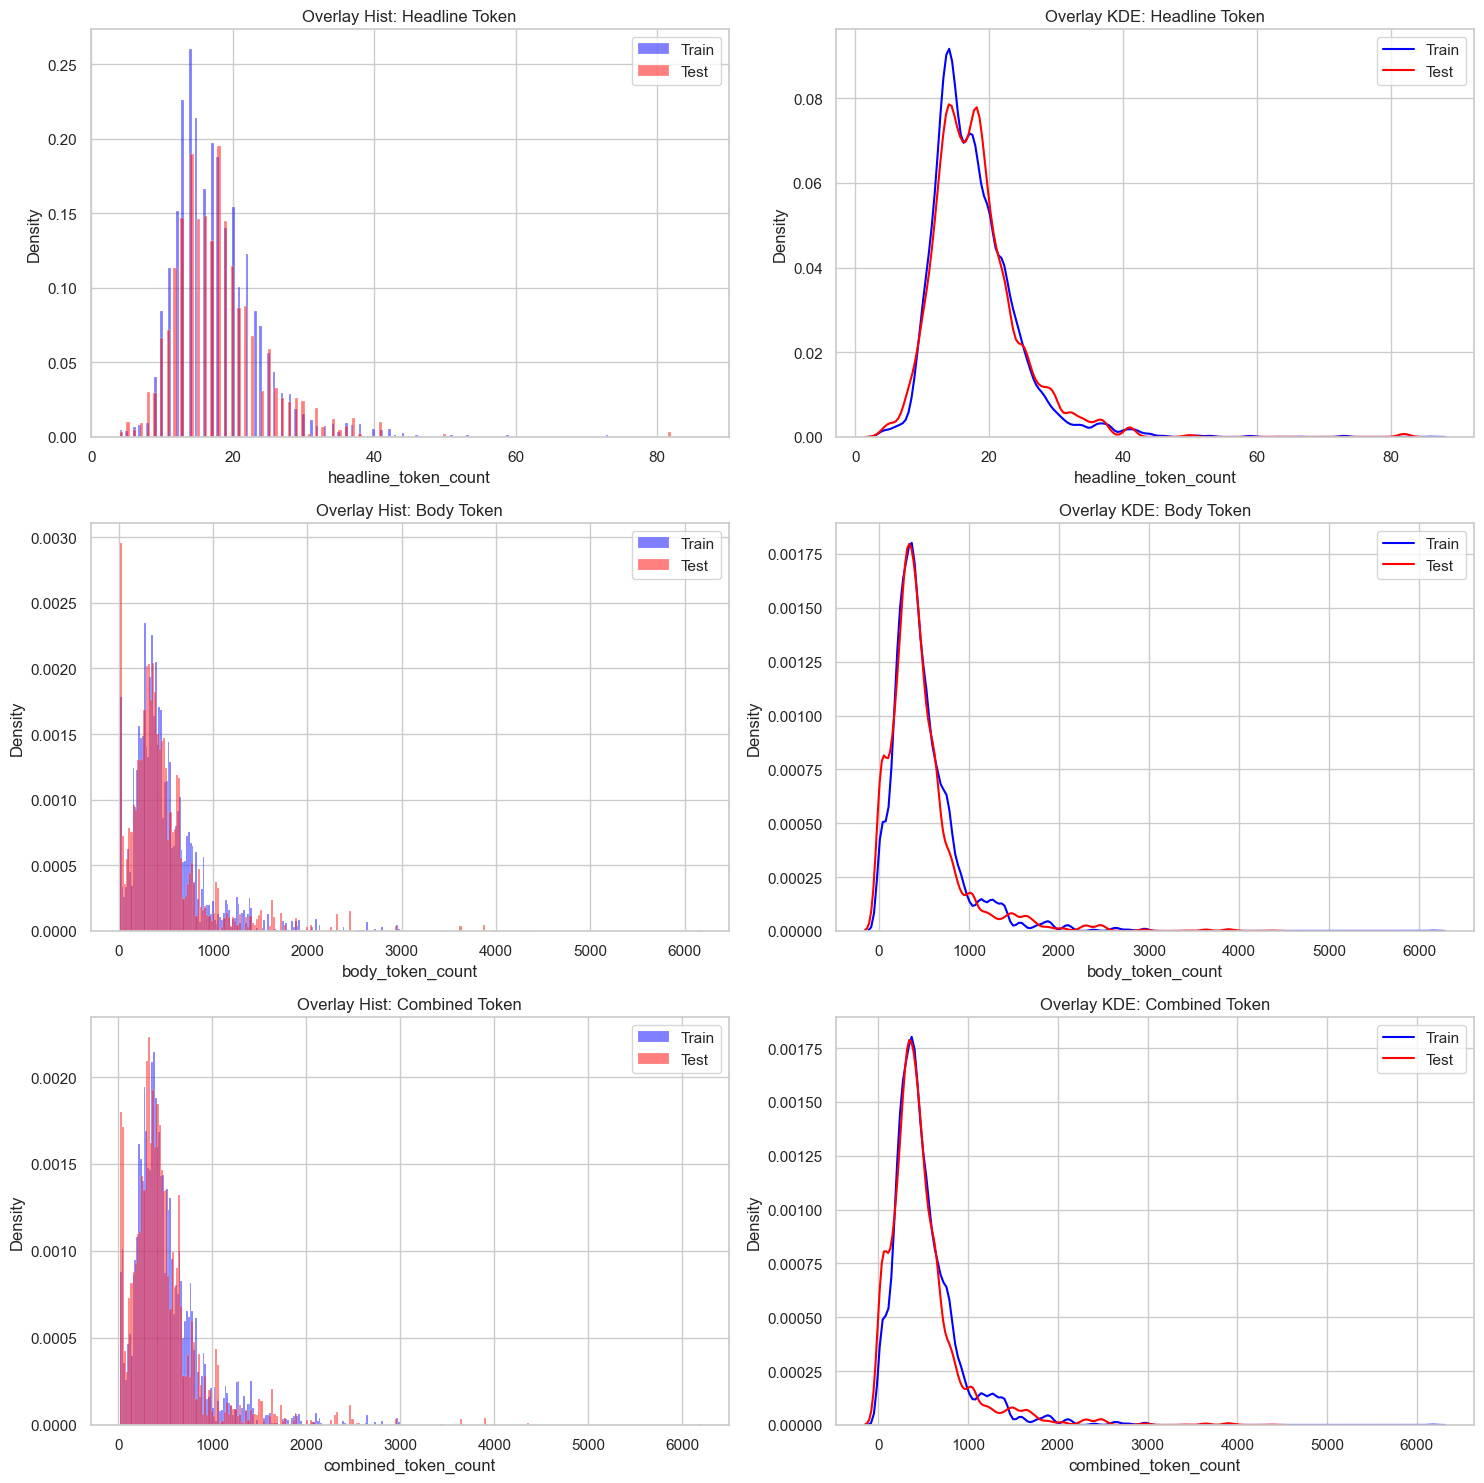

In [13]:
print("Memproses tokenisasi untuk Train set...")
df_train['headline_token_count'] = df_train['Headline'].apply(count_tokens)
df_train['body_token_count'] = df_train['articleBody'].apply(count_tokens)
df_train['combined_token_count'] = df_train.apply(lambda row: count_tokens(str(row['Headline']) + " " + str(row['articleBody'])), axis=1)

def comp_stats(col):
    return pd.DataFrame({
        'Train': calculate_token_stats(df_train[col]),
        'Test': calculate_token_stats(df_test[col])
    })

print("Perbandingan Headline:")
display(comp_stats('headline_token_count'))

print("Perbandingan Article Body:")
display(comp_stats('body_token_count'))

print("Perbandingan Combined (Headline + Body):")
display(comp_stats('combined_token_count'))

train_over = [(df_train['combined_token_count'] > t).mean() * 100 for t in [512, 1024, 2048]]
test_over = [(df_test['combined_token_count'] > t).mean() * 100 for t in [512, 1024, 2048]]

over_df = pd.DataFrame({'Train %': train_over, 'Test %': test_over}, index=['>512', '>1024', '>2048'])
print("Perbandingan Threshold (Combined):")
display(over_df)

# Visualisasi
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Headline
sns.histplot(df_train['headline_token_count'], color='blue', alpha=0.5, stat='density', ax=axes[0,0], label='Train')
sns.histplot(df_test['headline_token_count'], color='red', alpha=0.5, stat='density', ax=axes[0,0], label='Test')
axes[0,0].legend()
axes[0,0].set_title('Overlay Hist: Headline Token')

sns.kdeplot(df_train['headline_token_count'], color='blue', ax=axes[0,1], label='Train')
sns.kdeplot(df_test['headline_token_count'], color='red', ax=axes[0,1], label='Test')
axes[0,1].legend()
axes[0,1].set_title('Overlay KDE: Headline Token')

# Body
sns.histplot(df_train['body_token_count'], color='blue', alpha=0.5, stat='density', ax=axes[1,0], label='Train')
sns.histplot(df_test['body_token_count'], color='red', alpha=0.5, stat='density', ax=axes[1,0], label='Test')
axes[1,0].legend()
axes[1,0].set_title('Overlay Hist: Body Token')

sns.kdeplot(df_train['body_token_count'], color='blue', ax=axes[1,1], label='Train')
sns.kdeplot(df_test['body_token_count'], color='red', ax=axes[1,1], label='Test')
axes[1,1].legend()
axes[1,1].set_title('Overlay KDE: Body Token')

# Combined
sns.histplot(df_train['combined_token_count'], color='blue', alpha=0.5, stat='density', ax=axes[2,0], label='Train')
sns.histplot(df_test['combined_token_count'], color='red', alpha=0.5, stat='density', ax=axes[2,0], label='Test')
axes[2,0].legend()
axes[2,0].set_title('Overlay Hist: Combined Token')

sns.kdeplot(df_train['combined_token_count'], color='blue', ax=axes[2,1], label='Train')
sns.kdeplot(df_test['combined_token_count'], color='red', ax=axes[2,1], label='Test')
axes[2,1].legend()
axes[2,1].set_title('Overlay KDE: Combined Token')

plt.tight_layout()
plt.show()

**Insight Singkat:**
Berdasarkan overlay histogram dan KDE, distribusi panjang teks antara dataset Train dan Test sangat identik. Pembagian dataset terbukti proporsional.

==================================================
## SECTION 11 — FINAL MODEL VALIDATION
==================================================

In [14]:
val_data = {
    'Metric': ['Median Token', 'P95 Token', 'P99 Token', 'Max Token', '% >512', '% >1024', '% >2048'],
    'Train': [
        df_train['combined_token_count'].median(),
        df_train['combined_token_count'].quantile(0.95),
        df_train['combined_token_count'].quantile(0.99),
        df_train['combined_token_count'].max(),
        (df_train['combined_token_count'] > 512).mean() * 100,
        (df_train['combined_token_count'] > 1024).mean() * 100,
        (df_train['combined_token_count'] > 2048).mean() * 100
    ],
    'Test': [
        df_test['combined_token_count'].median(),
        df_test['combined_token_count'].quantile(0.95),
        df_test['combined_token_count'].quantile(0.99),
        df_test['combined_token_count'].max(),
        (df_test['combined_token_count'] > 512).mean() * 100,
        (df_test['combined_token_count'] > 1024).mean() * 100,
        (df_test['combined_token_count'] > 2048).mean() * 100
    ]
}

val_df = pd.DataFrame(val_data)
display(val_df)

,Metric,Train,Test
0,Median Token,425.000000,400.000000
1,P95 Token,1256.000000,1252.400000
2,P99 Token,1906.290000,2315.000000
3,Max Token,6184.000000,4371.000000
4,% >512,38.269431,32.876874
5,% >1024,7.778356,8.235942
6,% >2048,0.792444,1.243458


**Kesimpulan Akhir:**
1. **Distribusi Test vs Train:** Distribusi test set terbukti konsisten dan sangat merepresentasikan distribusi train set.
2. **Truncation 512 Token:** Truncation batas maksimum 512 token tetap rasional karena melindungi model dari out-of-memory errors dengan efek pemotongan yang minim terhadap total sampel.
3. **Context Window 1024 Token:** Menggunakan model dengan rentang 1024 token tidak memberikan benefit besar dan menaikkan biaya komputasi secara sia-sia.
4. **Keputusan Model (Longformer):** Penerapan model *long-sequence* seperti Longformer tidak esensial karena isu limitasi token ekstrem hanya ada pada minoritas sampel (outliers).
5. **Tantangan Utama Dataset:** Tantangannya jelas bukan pada pengolahan sekuens ekstra panjang, melainkan pada keakuratan _relational encoding_ antara dua buah teks (headline vs article body).